In [1]:
import argparse
import sys
sys.path.append('/home/igavier_umass_edu/Documents/Neuromorphic-IMU/snn/')
from har_snn import *

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import wandb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.metrics import classification_report, balanced_accuracy_score, f1_score, matthews_corrcoef, cohen_kappa_score

In [24]:
device = torch.device('cuda')

tc = 1.0 ###################################

In [25]:
kwargs = {}
kwargs.update([('shiftSyn', 2), ('shiftMem', 1)])
kwargs['timeResolution'] = 1./64
kwargs['tausFactor'] = 1.0

model = createModel(
    'SynNetRP',
    inputSize=15,
    outputSize=15, ###################################
    hiddenSizes=[80,80,80],
    device=device,
    sampleFreq=64,
    **kwargs
)

model_name = '2026-03-05T16:05:20.329430103+00:00_4gc8lf1g.pth' ###################################
state_dict = torch.load('/home/igavier_umass_edu/Documents/Neuromorphic-IMU/snn/models/'
                        + model_name, weights_only=True)

####################################
# If using Wisdm dataset
state = state_dict['seq.out_linear.weight']
state = torch.cat([state[:,:1], state[:,[1,8,9,11]].mean(1, keepdim=True), state[:,2:8], state[:,10:11], state[:,12:]], dim=1)
state_dict['seq.out_linear.weight'] = state
state = state_dict['seq.out_neurons.vmem']
state = torch.cat([state[:1], state[[1,8,9,11]].mean(0, keepdim=True), state[2:8], state[10:11], state[12:]], dim=0)
state_dict['seq.out_neurons.vmem'] = state
state = state_dict['seq.out_neurons.isyn']
state = torch.cat([state[:1], state[[1,8,9,11]].mean(0, keepdim=True), state[2:8], state[10:11], state[12:]], dim=0)
state_dict['seq.out_neurons.isyn'] = state
state = state_dict['seq.out_neurons.spikes']
state = torch.cat([state[:1], state[[1,8,9,11]].max(0, keepdim=True)[0], state[2:8], state[10:11], state[12:]], dim=0)
state_dict['seq.out_neurons.spikes'] = state

model.load_state_dict(state_dict)

WARNING    /home/igavier_umass_edu/Documents/Neuromorphic-IMU/snn/rockpool_nn_networks_synnet.py:127: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tau_to_bitshift(dt, torch.tensor(tau_mem.clone().detach()))[0]
 [py.warnings]
WARNING    /home/igavier_umass_edu/Documents/Neuromorphic-IMU/snn/rockpool_nn_networks_synnet.py:131: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tau_to_bitshift(dt, torch.tensor(tau_syn_out.clone().detach()))[0]
 [py.warnings]


<All keys matched successfully>

<Axes: >

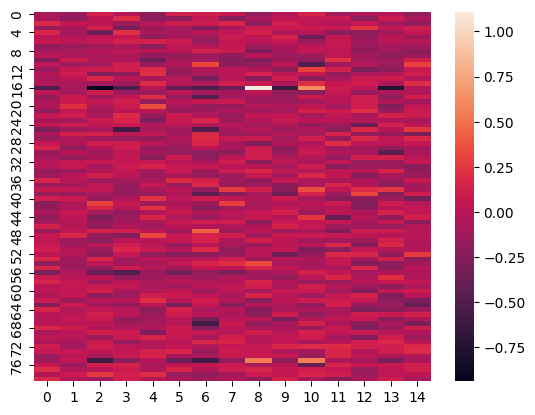

In [26]:
sn.heatmap(model.seq['out_linear'].weight.cpu().detach().numpy())

In [27]:
data_path = (f'/work/pi_sunghoonlee_umass_edu/Ignacio/wisdm/' +
             f'data/spikesXylo/windows/')
             # f'data/eventsNIMU/windows/') ###################################

train_loader, val_loader, test_loader = createLoaders(
    data_path,
    datasetName='Wisdm',
    labelType='Willetts2018',
    subjectSplits=(80,10,10),
    batchSize=1024,
    randomSeed=1, ###################################
    balance=False,
    sampleFreq=64,
    rectifySpikes=False, ###################################
    polarityBichannel=False,
    timeCompress=tc,
    timeResolution=1./64*tc,
    systemType='downsampled',
    quantizeSpikes=False ###################################
)

Subject splits: [array([19, 16, 29,  9, 24, 31, 23, 35,  3, 30, 20,  0, 15,  7,  6, 44, 22,
       17, 43, 25, 27, 21, 28,  1, 11, 45, 14,  4, 39, 42, 37, 33, 40, 26,
       34,  2]), array([12, 10, 36,  5,  8]), array([32, 41, 18, 13, 38])]
Subject splits: [array([19, 16, 29,  9, 24, 31, 23, 35,  3, 30, 20,  0, 15,  7,  6, 44, 22,
       17, 43, 25, 27, 21, 28,  1, 11, 45, 14,  4, 39, 42, 37, 33, 40, 26,
       34,  2]), array([12, 10, 36,  5,  8]), array([32, 41, 18, 13, 38])]
Subject splits: [array([19, 16, 29,  9, 24, 31, 23, 35,  3, 30, 20,  0, 15,  7,  6, 44, 22,
       17, 43, 25, 27, 21, 28,  1, 11, 45, 14,  4, 39, 42, 37, 33, 40, 26,
       34,  2]), array([12, 10, 36,  5,  8]), array([32, 41, 18, 13, 38])]


100%|██████████| 3/3 [00:16<00:00,  5.59s/it]


test (3039, 640, 15) (3039,)
[166 678 170 170 166 161 170 171 170 171 170 171 170 170 165]


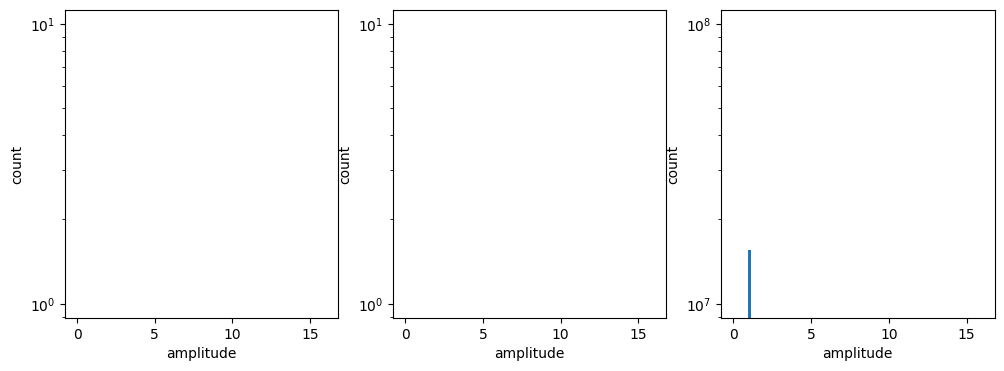

In [28]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=False)
[ax[i].set_yscale('log') for i in range(3)]
[ax[i].set_ylabel('count') for i in range(3)]
[ax[i].set_xlabel('amplitude') for i in range(3)]
i = 0
for name, loader, axi in zip(['train', 'val', 'test'], [train_loader, val_loader, test_loader], ax):
    if name in ('train', 'val'): continue
    inputs, labels = [], []
    for b, (inp, lab) in tqdm(enumerate(loader), total=len(loader)):
        #############################################
        # If using Wisdm dataset
        lab = torch.where(torch.isin(lab, torch.tensor([8,9,11])), 1, lab)
        lab = torch.where(lab == 10, 8, lab)
        lab = torch.where(lab >= 12, lab - 3, lab)
        #############################################
        inputs.append(inp.numpy())
        labels.append(lab.numpy())
        if b > 0 and b % 100 == 0:
            inputs, labels = np.concatenate(inputs, 0), np.concatenate(labels, 0)
            np.save('/home/igavier_umass_edu/Documents/Neuromorphic-IMU/snn/' +
                    f'datasets/Xylo_wisdm_{name}{b//100}_inputs_tc{int(tc)}.npy', inputs)
            np.save('/home/igavier_umass_edu/Documents/Neuromorphic-IMU/snn/' +
                    f'datasets/Xylo_wisdm_{name}{b//100}_labels_tc{int(tc)}.npy', labels)
            inputs, labels = [], []
    if b > 0 and b % 100 == 0: continue
    inputs, labels = np.concatenate(inputs, 0), np.concatenate(labels, 0)
    axi.hist(inputs[inputs!=0].reshape(-1), bins=np.linspace(0,16,101))
    i += 1
    print(name, inputs.shape, labels.shape)
    print(np.bincount(labels))
    np.save('/home/igavier_umass_edu/Documents/Neuromorphic-IMU/snn/' +
            f'datasets/Xylo_wisdm_{name}{b//100+1}_inputs_tc{int(tc)}.npy', inputs)
    np.save('/home/igavier_umass_edu/Documents/Neuromorphic-IMU/snn/' +
            f'datasets/Xylo_wisdm_{name}{b//100+1}_labels_tc{int(tc)}.npy', labels)

In [11]:
optimizer = torch.optim.Adam(model.parameters().astorch(), lr=1e-3)
criterion = CrossEntropySpkReg(alpha=0)
best_metric = 0.0

In [12]:
# model.reset_state()
test_metrics = run_epoch(model, test_loader, criterion, split='test', device=device)

  0%|          | 0/3 [00:00<?, ?it/s]/pytorch/aten/src/ATen/native/cuda/Loss.cu:250: nll_loss_forward_reduce_cuda_kernel_2d: block: [0,0,0], thread: [0,0,0] Assertion `t >= 0 && t < n_classes` failed.
/pytorch/aten/src/ATen/native/cuda/Loss.cu:250: nll_loss_forward_reduce_cuda_kernel_2d: block: [0,0,0], thread: [1,0,0] Assertion `t >= 0 && t < n_classes` failed.
/pytorch/aten/src/ATen/native/cuda/Loss.cu:250: nll_loss_forward_reduce_cuda_kernel_2d: block: [0,0,0], thread: [2,0,0] Assertion `t >= 0 && t < n_classes` failed.
/pytorch/aten/src/ATen/native/cuda/Loss.cu:250: nll_loss_forward_reduce_cuda_kernel_2d: block: [0,0,0], thread: [3,0,0] Assertion `t >= 0 && t < n_classes` failed.
/pytorch/aten/src/ATen/native/cuda/Loss.cu:250: nll_loss_forward_reduce_cuda_kernel_2d: block: [0,0,0], thread: [4,0,0] Assertion `t >= 0 && t < n_classes` failed.
/pytorch/aten/src/ATen/native/cuda/Loss.cu:250: nll_loss_forward_reduce_cuda_kernel_2d: block: [0,0,0], thread: [5,0,0] Assertion `t >= 0 && t 

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
